# Multi-task ViT — inference on one image per class

For each morphological task, pick **one example image per severity class** (`0`, `+`, `++`, `+++`) from the fold-0 test predictions, run the model, and compare GT vs prediction.

Default paths point to the cluster dataset mount.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from IPython.display import display

# repo root = notebook directory
ROOT = Path.cwd()
if not (ROOT / "Model").exists() and (ROOT.parent / "Model").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from infer import (
    TASKS,
    TASK_DISPLAY,
    SEVERITY,
    load_model,
    predict_one,
)

CLUSTER_BASE = Path("/cluster/dataset/medinfmk/capillaroscopy")
CHECKPOINT = CLUSTER_BASE / "Nail-Imaging/multi-task/multiTask/0/pytorch_model.bin"
PRED_CSV = CLUSTER_BASE / "Nail-Imaging/multi-task/image_ids_test-set_0.csv"
IMAGE_ROOT = CLUSTER_BASE / "content/images"

# Local fallbacks
LOCAL_CHECKPOINT = ROOT / "data/multi-task/multiTask/0/pytorch_model.bin"
LOCAL_PRED_CSV = ROOT / "data/multi-task/image_ids_test-set_0.csv"
LOCAL_IMAGE_ROOTS = [
    Path("/Users/farhadzn/Projects/Projects_UZH/Capillaroscopy/content/images"),
    ROOT.parent / "Capillaroscopy/content/images",
    ROOT / "data/images",
]

if not CHECKPOINT.is_file() and LOCAL_CHECKPOINT.is_file():
    CHECKPOINT = LOCAL_CHECKPOINT
if not PRED_CSV.is_file() and LOCAL_PRED_CSV.is_file():
    PRED_CSV = LOCAL_PRED_CSV
if not IMAGE_ROOT.is_dir():
    for cand in LOCAL_IMAGE_ROOTS:
        if cand.is_dir():
            IMAGE_ROOT = cand
            break

OUT_DIR = ROOT / "infer_examples_outputs"
OUT_DIR.mkdir(exist_ok=True)

def resolve_image_path(path: str) -> Path:
    p = Path(path)
    if p.is_file():
        return p
    name = Path(path).name
    candidate = IMAGE_ROOT / name
    if candidate.is_file():
        return candidate
    for prefix in (
        "/opt/data/capillaroscopy/content/images/",
        "/cluster/dataset/medinfmk/capillaroscopy/content/images/",
    ):
        if str(path).startswith(prefix):
            remapped = IMAGE_ROOT / name
            if remapped.is_file():
                return remapped
    return p

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint:", CHECKPOINT)
print("predictions CSV:", PRED_CSV)
print("image root:", IMAGE_ROOT)
print("output dir:", OUT_DIR)


device: cpu
checkpoint: /Users/farhadzn/Projects/Projects_UZH/Nail-Imaging/data/multi-task/multiTask/0/pytorch_model.bin
predictions CSV: /Users/farhadzn/Projects/Projects_UZH/Nail-Imaging/data/multi-task/image_ids_test-set_0.csv
image root: /Users/farhadzn/Projects/Projects_UZH/Capillaroscopy/content/images
output dir: /Users/farhadzn/Projects/Projects_UZH/Nail-Imaging/infer_examples_outputs


In [2]:
assert CHECKPOINT.is_file(), f"Checkpoint not found: {CHECKPOINT}"
assert PRED_CSV.is_file(), f"CSV not found: {PRED_CSV}"

df = pd.read_csv(PRED_CSV, index_col=0)
df.index = df.index.map(lambda x: str(resolve_image_path(x)))
print(f"Loaded {len(df)} test images")
df.head(2)

Loaded 4041 test images


,finger_dilatierte,finger_riesen,finger_rare,finger_mikro,finger_dilatierte_p,finger_riesen_p,finger_rare_p,finger_mikro_p
/Users/farhadzn/Projects/Projects_UZH/Capillaroscopy/content/images/20201128200608_3e071a4d-6779-42df-ae55-78a6902ac355.jpg,0,0,1,0,0,0,0,0
/Users/farhadzn/Projects/Projects_UZH/Capillaroscopy/content/images/20201128200608_2ec196c2-923d-4ee3-b272-436b8a46ecf3.jpg,0,0,1,0,0,0,0,0


In [3]:
model = load_model(str(CHECKPOINT), device)
print("Model loaded.")

Model loaded.


## Pick one image per severity class

For every task, take the first available test image whose **ground-truth** severity is `0`, `+`, `++`, or `+++` (skip missing grades).

In [4]:
def pick_one_per_class(frame: pd.DataFrame, task: str):
    """Return {class_id: image_path} for classes present in GT."""
    chosen = {}
    for class_id in range(4):
        subset = frame[frame[task] == class_id]
        # prefer images that exist on disk
        for path in subset.index:
            if Path(path).is_file():
                chosen[class_id] = path
                break
        else:
            if len(subset):
                chosen[class_id] = subset.index[0]  # record even if missing; will skip later
    return chosen


examples = {task: pick_one_per_class(df, task) for task in TASKS}
for task, mapping in examples.items():
    print(TASK_DISPLAY[task], {SEVERITY[k]: Path(v).name for k, v in mapping.items()})

enlarged capillaries {'0': '20201128200608_3e071a4d-6779-42df-ae55-78a6902ac355.jpg', '+': '20201128201213_f5493a00-c7d7-448f-8c3c-0ed0f907955d.jpg', '++': '20201128200815_b85e2c87-4b1a-47ec-90c0-bf6346b2af28.jpg'}
giant capillaries {'0': '20201128200608_3e071a4d-6779-42df-ae55-78a6902ac355.jpg', '+': '20201128200609_ba604e39-1e5e-4f87-8337-a50b31ddb9b5.jpg', '++': '20201128200827_26567557-d507-40f1-bd5b-87c440e8beb9.jpg', '+++': '20201128200627_47f1a482-f087-4940-a97b-5e157161423b.jpg'}
capillary loss {'0': '20201128201213_f5493a00-c7d7-448f-8c3c-0ed0f907955d.jpg', '+': '20201128200608_3e071a4d-6779-42df-ae55-78a6902ac355.jpg', '++': '20201128200609_e9956c4d-5506-4ee2-aff3-d4c06f181396.jpg', '+++': '20201128200609_b9c1d4fd-7c69-4cf1-ac47-f9c9a9bda409.jpg'}
microhaemorrhages {'0': '20201128200608_3e071a4d-6779-42df-ae55-78a6902ac355.jpg', '+': '20201128201353_884a2e80-3697-4830-ab42-b3dd8b000ed1.jpg', '++': '20201128201355_835536f6-ccbd-455b-a765-239210318c57.jpg', '+++': '202011282005

## Run inference and plot

saved /Users/farhadzn/Projects/Projects_UZH/Nail-Imaging/infer_examples_outputs/finger_dilatierte_examples.png


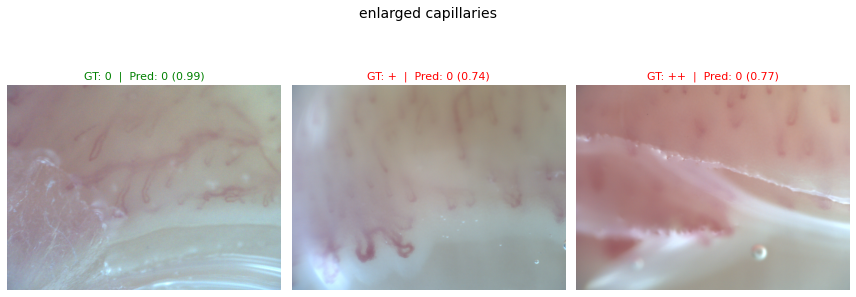

,task,gt,pred,confidence,correct,image
0,enlarged capillaries,0,0,0.99,True,20201128200608_3e071a4d-6779-42df-ae55-78a6902...
1,enlarged capillaries,+,0,0.74,False,20201128201213_f5493a00-c7d7-448f-8c3c-0ed0f90...
2,enlarged capillaries,++,0,0.77,False,20201128200815_b85e2c87-4b1a-47ec-90c0-bf6346b...


saved /Users/farhadzn/Projects/Projects_UZH/Nail-Imaging/infer_examples_outputs/finger_riesen_examples.png


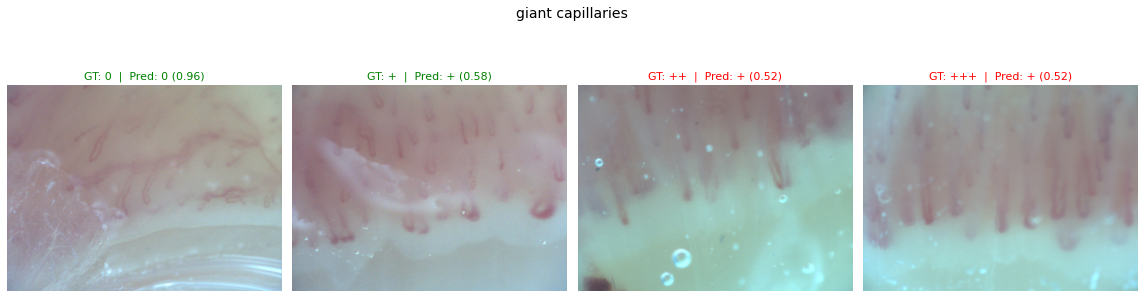

,task,gt,pred,confidence,correct,image
0,giant capillaries,0,0,0.961,True,20201128200608_3e071a4d-6779-42df-ae55-78a6902...
1,giant capillaries,+,+,0.579,True,20201128200609_ba604e39-1e5e-4f87-8337-a50b31d...
2,giant capillaries,++,+,0.520,False,20201128200827_26567557-d507-40f1-bd5b-87c440e...
3,giant capillaries,+++,+,0.517,False,20201128200627_47f1a482-f087-4940-a97b-5e15716...


saved /Users/farhadzn/Projects/Projects_UZH/Nail-Imaging/infer_examples_outputs/finger_rare_examples.png


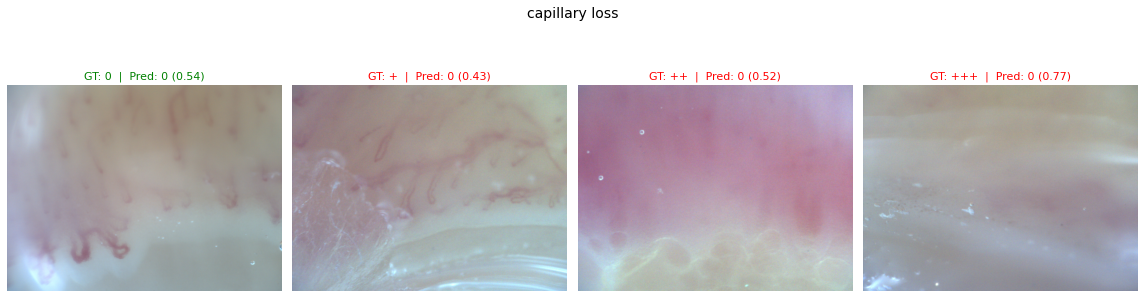

,task,gt,pred,confidence,correct,image
0,capillary loss,0,0,0.539,True,20201128201213_f5493a00-c7d7-448f-8c3c-0ed0f90...
1,capillary loss,+,0,0.434,False,20201128200608_3e071a4d-6779-42df-ae55-78a6902...
2,capillary loss,++,0,0.518,False,20201128200609_e9956c4d-5506-4ee2-aff3-d4c06f1...
3,capillary loss,+++,0,0.769,False,20201128200609_b9c1d4fd-7c69-4cf1-ac47-f9c9a9b...


saved /Users/farhadzn/Projects/Projects_UZH/Nail-Imaging/infer_examples_outputs/finger_mikro_examples.png


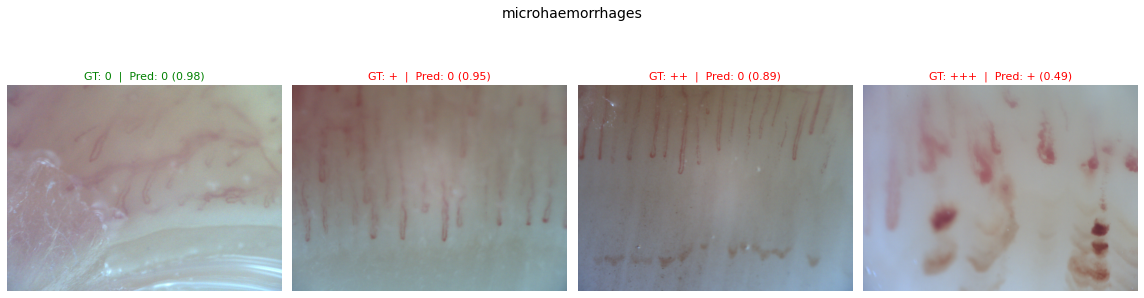

,task,gt,pred,confidence,correct,image
0,microhaemorrhages,0,0,0.985,True,20201128200608_3e071a4d-6779-42df-ae55-78a6902...
1,microhaemorrhages,+,0,0.954,False,20201128201353_884a2e80-3697-4830-ab42-b3dd8b0...
2,microhaemorrhages,++,0,0.885,False,20201128201355_835536f6-ccbd-455b-a765-2392103...
3,microhaemorrhages,+++,+,0.488,False,20201128200559_047f192d-f9e5-49c3-be65-a020f42...


In [5]:
from IPython.display import display

def run_and_show(task: str, examples_for_task: dict):
    class_ids = sorted(examples_for_task)
    n = len(class_ids)
    if n == 0:
        print(f"No examples for {task}")
        return

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.5))
    if n == 1:
        axes = [axes]

    rows = []
    for ax, class_id in zip(axes, class_ids):
        path = examples_for_task[class_id]
        gt = SEVERITY[class_id]
        if not Path(path).is_file():
            ax.set_title(f"GT {gt}\n(missing file)")
            ax.axis("off")
            rows.append({"task": task, "gt": gt, "pred": None, "path": path, "ok": False})
            continue

        preds = predict_one(model, path, device)
        pred = preds[task]["label"]
        conf = preds[task]["probs"][pred]
        img = Image.open(path).convert("RGB")
        ax.imshow(img)
        color = "green" if pred == gt else "red"
        ax.set_title(f"GT: {gt}  |  Pred: {pred} ({conf:.2f})", color=color, fontsize=11)
        ax.axis("off")
        rows.append(
            {
                "task": TASK_DISPLAY[task],
                "gt": gt,
                "pred": pred,
                "confidence": round(conf, 3),
                "correct": pred == gt,
                "image": Path(path).name,
            }
        )

    fig.suptitle(TASK_DISPLAY[task], fontsize=14, y=1.02)
    plt.tight_layout()
    out_png = OUT_DIR / f"{task}_examples.png"
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    print("saved", out_png)
    plt.show()
    return pd.DataFrame(rows)


summary_tables = []
for task in TASKS:
    table = run_and_show(task, examples[task])
    if table is not None and len(table):
        summary_tables.append(table)
        display(table)



## Summary

In [6]:
if summary_tables:
    summary = pd.concat(summary_tables, ignore_index=True)
    display(summary)
    summary_path = OUT_DIR / "summary.csv"
    summary.to_csv(summary_path, index=False)
    print("saved", summary_path)
    if "correct" in summary.columns:
        print("Accuracy on these hand-picked examples:", summary["correct"].mean())
else:
    print("No images were found on disk. Run this notebook on the cluster where IMAGE_ROOT exists.")



,task,gt,pred,confidence,correct,image
0,enlarged capillaries,0,0,0.990,True,20201128200608_3e071a4d-6779-42df-ae55-78a6902...
1,enlarged capillaries,+,0,0.740,False,20201128201213_f5493a00-c7d7-448f-8c3c-0ed0f90...
2,enlarged capillaries,++,0,0.770,False,20201128200815_b85e2c87-4b1a-47ec-90c0-bf6346b...
3,giant capillaries,0,0,0.961,True,20201128200608_3e071a4d-6779-42df-ae55-78a6902...
4,giant capillaries,+,+,0.579,True,20201128200609_ba604e39-1e5e-4f87-8337-a50b31d...
5,giant capillaries,++,+,0.520,False,20201128200827_26567557-d507-40f1-bd5b-87c440e...
6,giant capillaries,+++,+,0.517,False,20201128200627_47f1a482-f087-4940-a97b-5e15716...
7,capillary loss,0,0,0.539,True,20201128201213_f5493a00-c7d7-448f-8c3c-0ed0f90...
8,capillary loss,+,0,0.434,False,20201128200608_3e071a4d-6779-42df-ae55-78a6902...
9,capillary loss,++,0,0.518,False,20201128200609_e9956c4d-5506-4ee2-aff3-d4c06f1...


saved /Users/farhadzn/Projects/Projects_UZH/Nail-Imaging/infer_examples_outputs/summary.csv
Accuracy on these hand-picked examples: 0.3333333333333333
